# **Data Preprocessing**

In [ ]:
import kagglehub
import pandas as pd
import os
from scipy.stats import zscore
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("meharshanali/student-dropout-prediction-dataset")
file_path = os.path.join(path, "student_dropout_dataset_v3.csv")
df = pd.read_csv(file_path)
df.head()


Using Colab cache for faster access to the 'student-dropout-prediction-dataset' dataset.


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [ ]:
# Replace missing values with median
df['Parental_Education'] = df['Parental_Education'].fillna('None')

df['Family_Income'] = df['Family_Income'].fillna(
    df.groupby('Parental_Education')['Family_Income'].transform('median')
)
df['Study_Hours_per_Day'] = df['Study_Hours_per_Day'].fillna(
    df.groupby(['Semester', 'Department', 'Part_Time_Job'])
    ['Study_Hours_per_Day'].transform('median')
)
df['Stress_Index'] = df['Stress_Index'].fillna(
    df.groupby(['Semester', 'Department', 'Part_Time_Job'])
    ['Stress_Index'].transform('median')
)

df.isna().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,0
Internet_Access,0
Study_Hours_per_Day,0
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


# **Basic Data Exploration**
Our dataset contains data that represents an academic environment. There are 19 features, including student age, gender, family income, access to internet, average study hours per day, attendance rate, assignment delay, commute time, part time job, scholarship, stress index, gpa, current year, department, and highest level of parental education. These features can be analyzed to predict and determine student academic performance and dropout. There are 10,000 entries in the dataset, representing 10,000 different students in an academic setting.

Hypothesis Testing: Effect of GPA on Student Dropout

To determine whether academic performance impacts student dropout, we compare GPA between students who dropped out and those who did not.

Null Hypothesis (H₀): There is no significant difference in GPA between students who drop out and those who do not.

Alternative Hypothesis (H₁): There is a significant difference in GPA between students who drop out and those who do not.

We can use an independent two-sample t-test.


In [ ]:
from scipy.stats import ttest_ind

dropout_group = df[df['Dropout'] == 1]['GPA'].dropna()
non_dropout_group = df[df['Dropout'] == 0]['GPA'].dropna()

t_stat, p_value = ttest_ind(dropout_group, non_dropout_group, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)
print("Mean GPA (Dropout):", dropout_group.mean())
print("Mean GPA (Non-Dropout):", non_dropout_group.mean())

# interpretation (IMPORTANT — matches your partner style)
if p_value < 0.05:
    print("Reject H0: GPA and dropout are significantly different")
else:
    print("Fail to reject H0: No significant difference in GPA between groups")



T-statistic: -52.998304100953824
P-value: 0.0
Mean GPA (Dropout): 1.4276125743415464
Mean GPA (Non-Dropout): 2.5796233324614177
Reject H0: GPA and dropout are significantly different


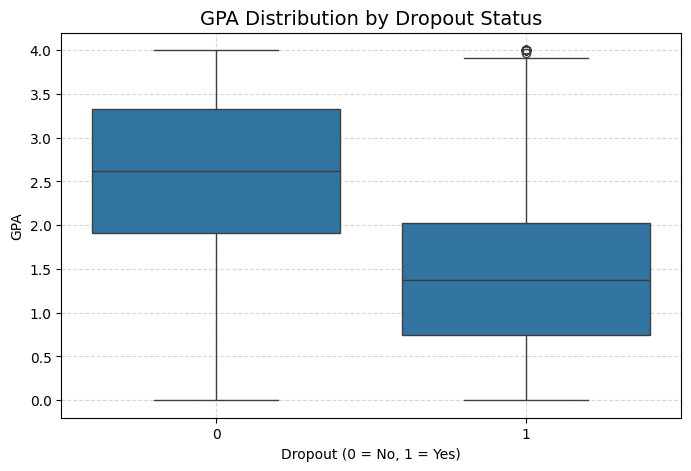

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x='Dropout', y='GPA', data=df)

plt.title("GPA Distribution by Dropout Status", fontsize=14)
plt.xlabel("Dropout (0 = No, 1 = Yes)")
plt.ylabel("GPA")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

There are 20 outliers total


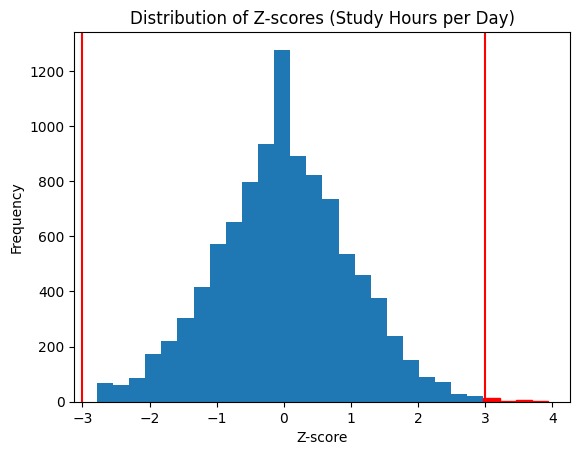

In [ ]:
#Find outliers in Study_Hours_per_Day using z-score analysis
z_scores = zscore(df['Study_Hours_per_Day'])
outliers = df[abs(z_scores) > 3]
print("There are " + str(len(outliers)) + " outliers total")

plt.figure()

counts, bins, patches = plt.hist(z_scores, bins=28)

for i in range(len(patches)):
    if bins[i] < -3 or bins[i+1] > 3:
        patches[i].set_color('red')

plt.axvline(3, color='red')
plt.axvline(-3, color='red')

plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.title("Distribution of Z-scores (Study Hours per Day)")

plt.show()

Correlation Test


We are looking to explore whether the a students scholarship status affects their droupout rate. We will use a chi sqaure test for this.

H0: Having a scholarship does not affect whether a student drops out.


Ha: Having a scholarship does affect whether a student drops out.

In [ ]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt


table  = pd.crosstab(df["Scholarship"], df["Dropout"])


ch12, p, dof, exp = chi2_contingency(table)


print("Chi-square stat:", ch12)


print("P-Value:" , p)


if p<0.05:
 print("Reject H0 which is scholarship and droupout are associated")
else:
 print("Fail to reject H0 which is there is no statistically significant assocation between scholarship and droupout.")






Chi-square stat: 0.41146114076497986
P-Value: 0.5212288181760807
Fail to reject H0 which is there is no statistically significant assocation between scholarship and droupout.


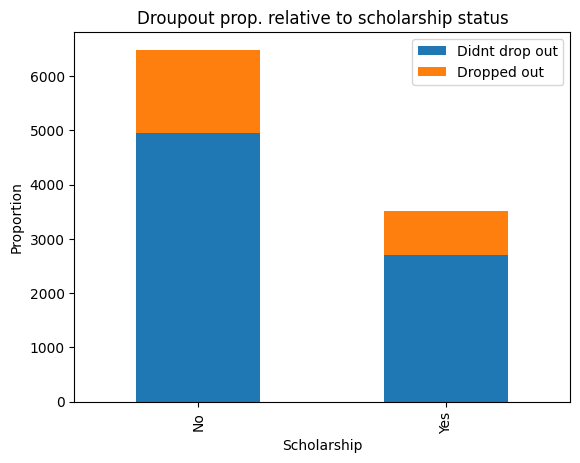

In [ ]:
new_table  = pd.crosstab(df["Scholarship"], df["Dropout"])
new_table.columns = ["Didnt drop out", "Dropped out"]
new_table.plot(kind ="bar", stacked = "True")
plt.title("Droupout prop. relative to scholarship status")
plt.ylabel("Proportion")
plt.xlabel("Scholarship")
plt.show()
